In [14]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
import matplotlib.ticker as ticker



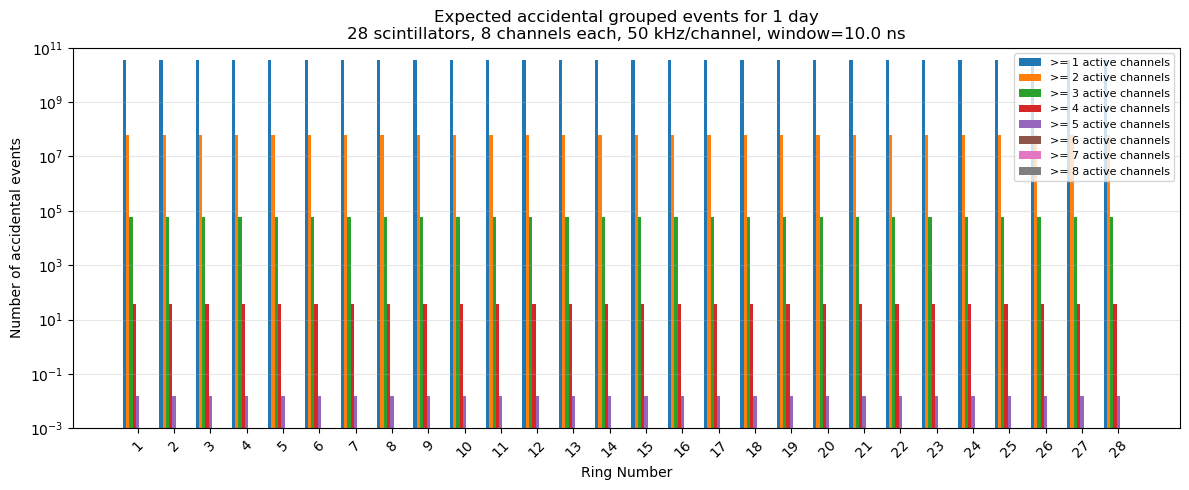

In [15]:
def expected_accidentals(
    n_scintillators=28,
    n_channels=8,
    rate_hz=50_000,
    grouping_window_s=10e-9,
    run_time_s=60*24*3600,   # 1 day default
):
    """
    Expected accidental events per scintillator for >=k active channels.
    Assumes independent Poisson hits per channel.
    """

    # probability one channel fires at least once in the grouping window
    p = 1 - np.exp(-rate_hz * grouping_window_s)

    thresholds = np.arange(1, n_channels + 1)

    expected = np.zeros((n_scintillators, n_channels))

    n_windows = run_time_s / grouping_window_s

    for s in range(n_scintillators):
        for k in thresholds:
            prob_ge_k = sum(
                comb(n_channels, j) * p**j * (1 - p)**(n_channels - j)
                for j in range(k, n_channels + 1)
            )
            expected[s, k-1] = prob_ge_k * n_windows

    return thresholds, expected


# -------------------------------
# User inputs
# -------------------------------
n_scintillators = 28
n_channels = 8
rate_hz = 50_000
grouping_window_s = 10e-9
run_time_s = 60 * 60 * 24  # sec

thresholds, expected = expected_accidentals(
    n_scintillators=n_scintillators,
    n_channels=n_channels,
    rate_hz=rate_hz,
    grouping_window_s=grouping_window_s,
    run_time_s=run_time_s,
)

# -------------------------------
# Plot grouped bar chart
# -------------------------------
rings = np.arange(1, n_scintillators + 1)

plt.figure(figsize=(12, 5))

bar_width = 0.09

for i, k in enumerate(thresholds):
    x = rings + (i - len(thresholds)/2) * bar_width
    plt.bar(
        x,
        expected[:, i],
        width=bar_width,
        label=f">= {k} active channels"
    )

plt.xlabel("Ring Number")
plt.ylabel("Number of accidental events")
plt.title(
    f"Expected accidental grouped events for 1 day\n"
    f"{n_scintillators} scintillators, {n_channels} channels each, "
    f"{rate_hz/1000:.0f} kHz/channel, window={grouping_window_s*1e9:.1f} ns"
)

plt.xticks(rings, rotation=45)
plt.yscale("log")

plt.ylim([1e-3,1e11])
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

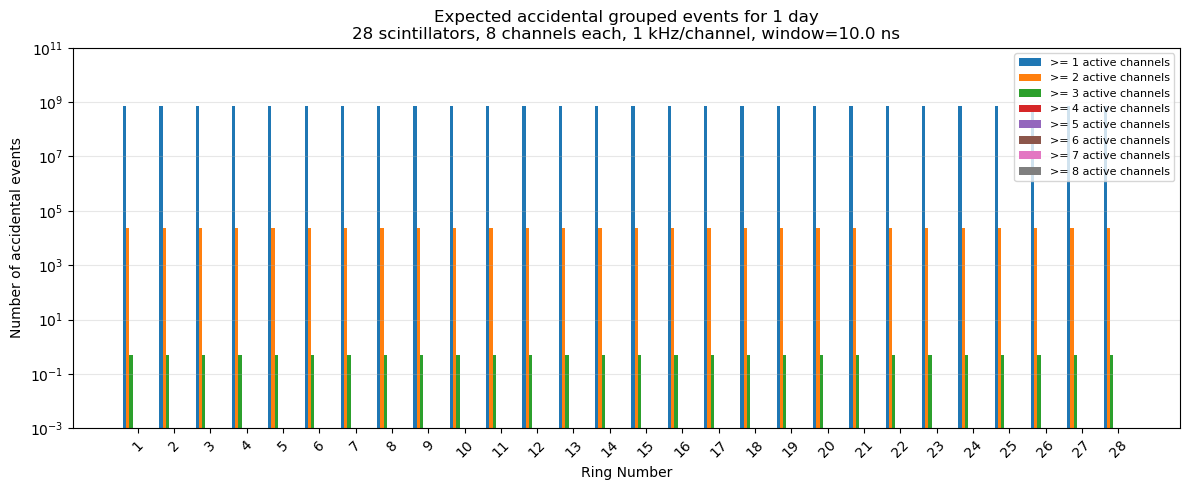

In [14]:
# -------------------------------
# User inputs
# -------------------------------
n_scintillators = 28
n_channels = 8
rate_hz = 1_000
grouping_window_s = 10e-9
run_time_s = 60 * 60 * 24  # sec

thresholds, expected = expected_accidentals(
    n_scintillators=n_scintillators,
    n_channels=n_channels,
    rate_hz=rate_hz,
    grouping_window_s=grouping_window_s,
    run_time_s=run_time_s,
)

# -------------------------------
# Plot grouped bar chart
# -------------------------------
rings = np.arange(1, n_scintillators + 1)

plt.figure(figsize=(12, 5))

bar_width = 0.09

for i, k in enumerate(thresholds):
    x = rings + (i - len(thresholds)/2) * bar_width
    plt.bar(
        x,
        expected[:, i],
        width=bar_width,
        label=f">= {k} active channels"
    )

plt.xlabel("Ring Number")
plt.ylabel("Number of accidental events")
plt.title(
    f"Expected accidental grouped events for 1 day\n"
    f"{n_scintillators} scintillators, {n_channels} channels each, "
    f"{rate_hz/1000:.0f} kHz/channel, window={grouping_window_s*1e9:.1f} ns"
)

plt.xticks(rings, rotation=45)
plt.yscale("log")

plt.ylim([1e-3,1e11])
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

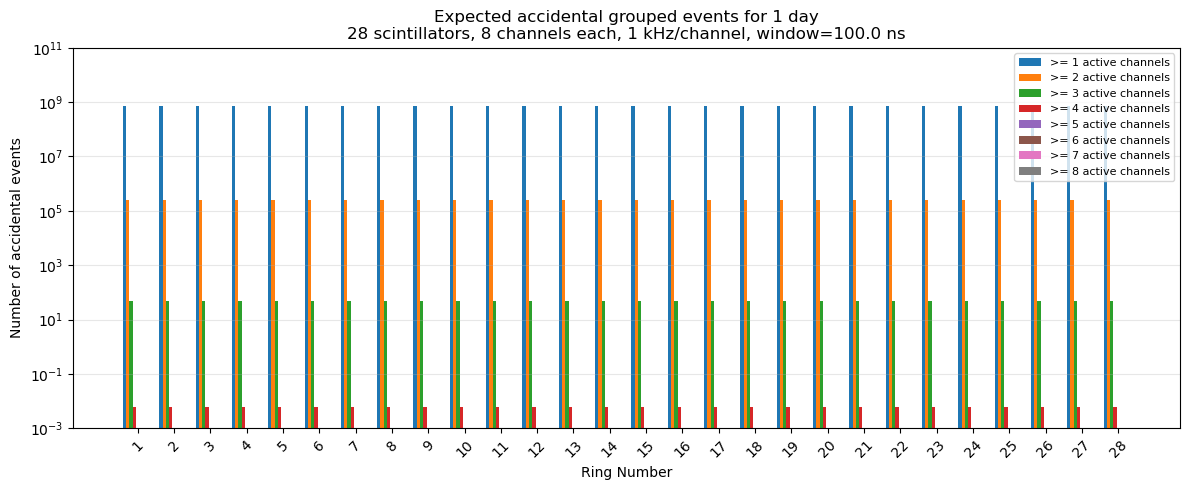

In [15]:
# -------------------------------
# User inputs
# -------------------------------
n_scintillators = 28
n_channels = 8
rate_hz = 1_000
grouping_window_s = 100e-9
run_time_s = 60 * 60 * 24  # sec

thresholds, expected = expected_accidentals(
    n_scintillators=n_scintillators,
    n_channels=n_channels,
    rate_hz=rate_hz,
    grouping_window_s=grouping_window_s,
    run_time_s=run_time_s,
)

# -------------------------------
# Plot grouped bar chart
# -------------------------------
rings = np.arange(1, n_scintillators + 1)

plt.figure(figsize=(12, 5))

bar_width = 0.09

for i, k in enumerate(thresholds):
    x = rings + (i - len(thresholds)/2) * bar_width
    plt.bar(
        x,
        expected[:, i],
        width=bar_width,
        label=f">= {k} active channels"
    )

plt.xlabel("Ring Number")
plt.ylabel("Number of accidental events")
plt.title(
    f"Expected accidental grouped events for 1 day\n"
    f"{n_scintillators} scintillators, {n_channels} channels each, "
    f"{rate_hz/1000:.0f} kHz/channel, window={grouping_window_s*1e9:.1f} ns"
)

plt.xticks(rings, rotation=45)
plt.yscale("log")

plt.ylim([1e-3,1e11])
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Accidental background per bar
---------------------------------------------
Requirement | P per 25us window | Rate/bar [Hz] | Events/bar in run
---------------------------------------------
>= 1 channels | 1.000e+00 | 1.000e+03 | 5.184e+09
>= 2 channels | 1.730e-02 | 1.730e+01 | 8.971e+07
>= 3 channels | 1.745e-05 | 1.745e-02 | 9.048e+04
>= 4 channels | 1.091e-08 | 1.091e-05 | 5.655e+01
>= 5 channels | 4.441e-12 | 4.441e-09 | 2.302e-02
>= 6 channels | 0.000e+00 | 0.000e+00 | 0.000e+00
>= 7 channels | 0.000e+00 | 0.000e+00 | 0.000e+00
>= 8 channels | 0.000e+00 | 0.000e+00 | 0.000e+00


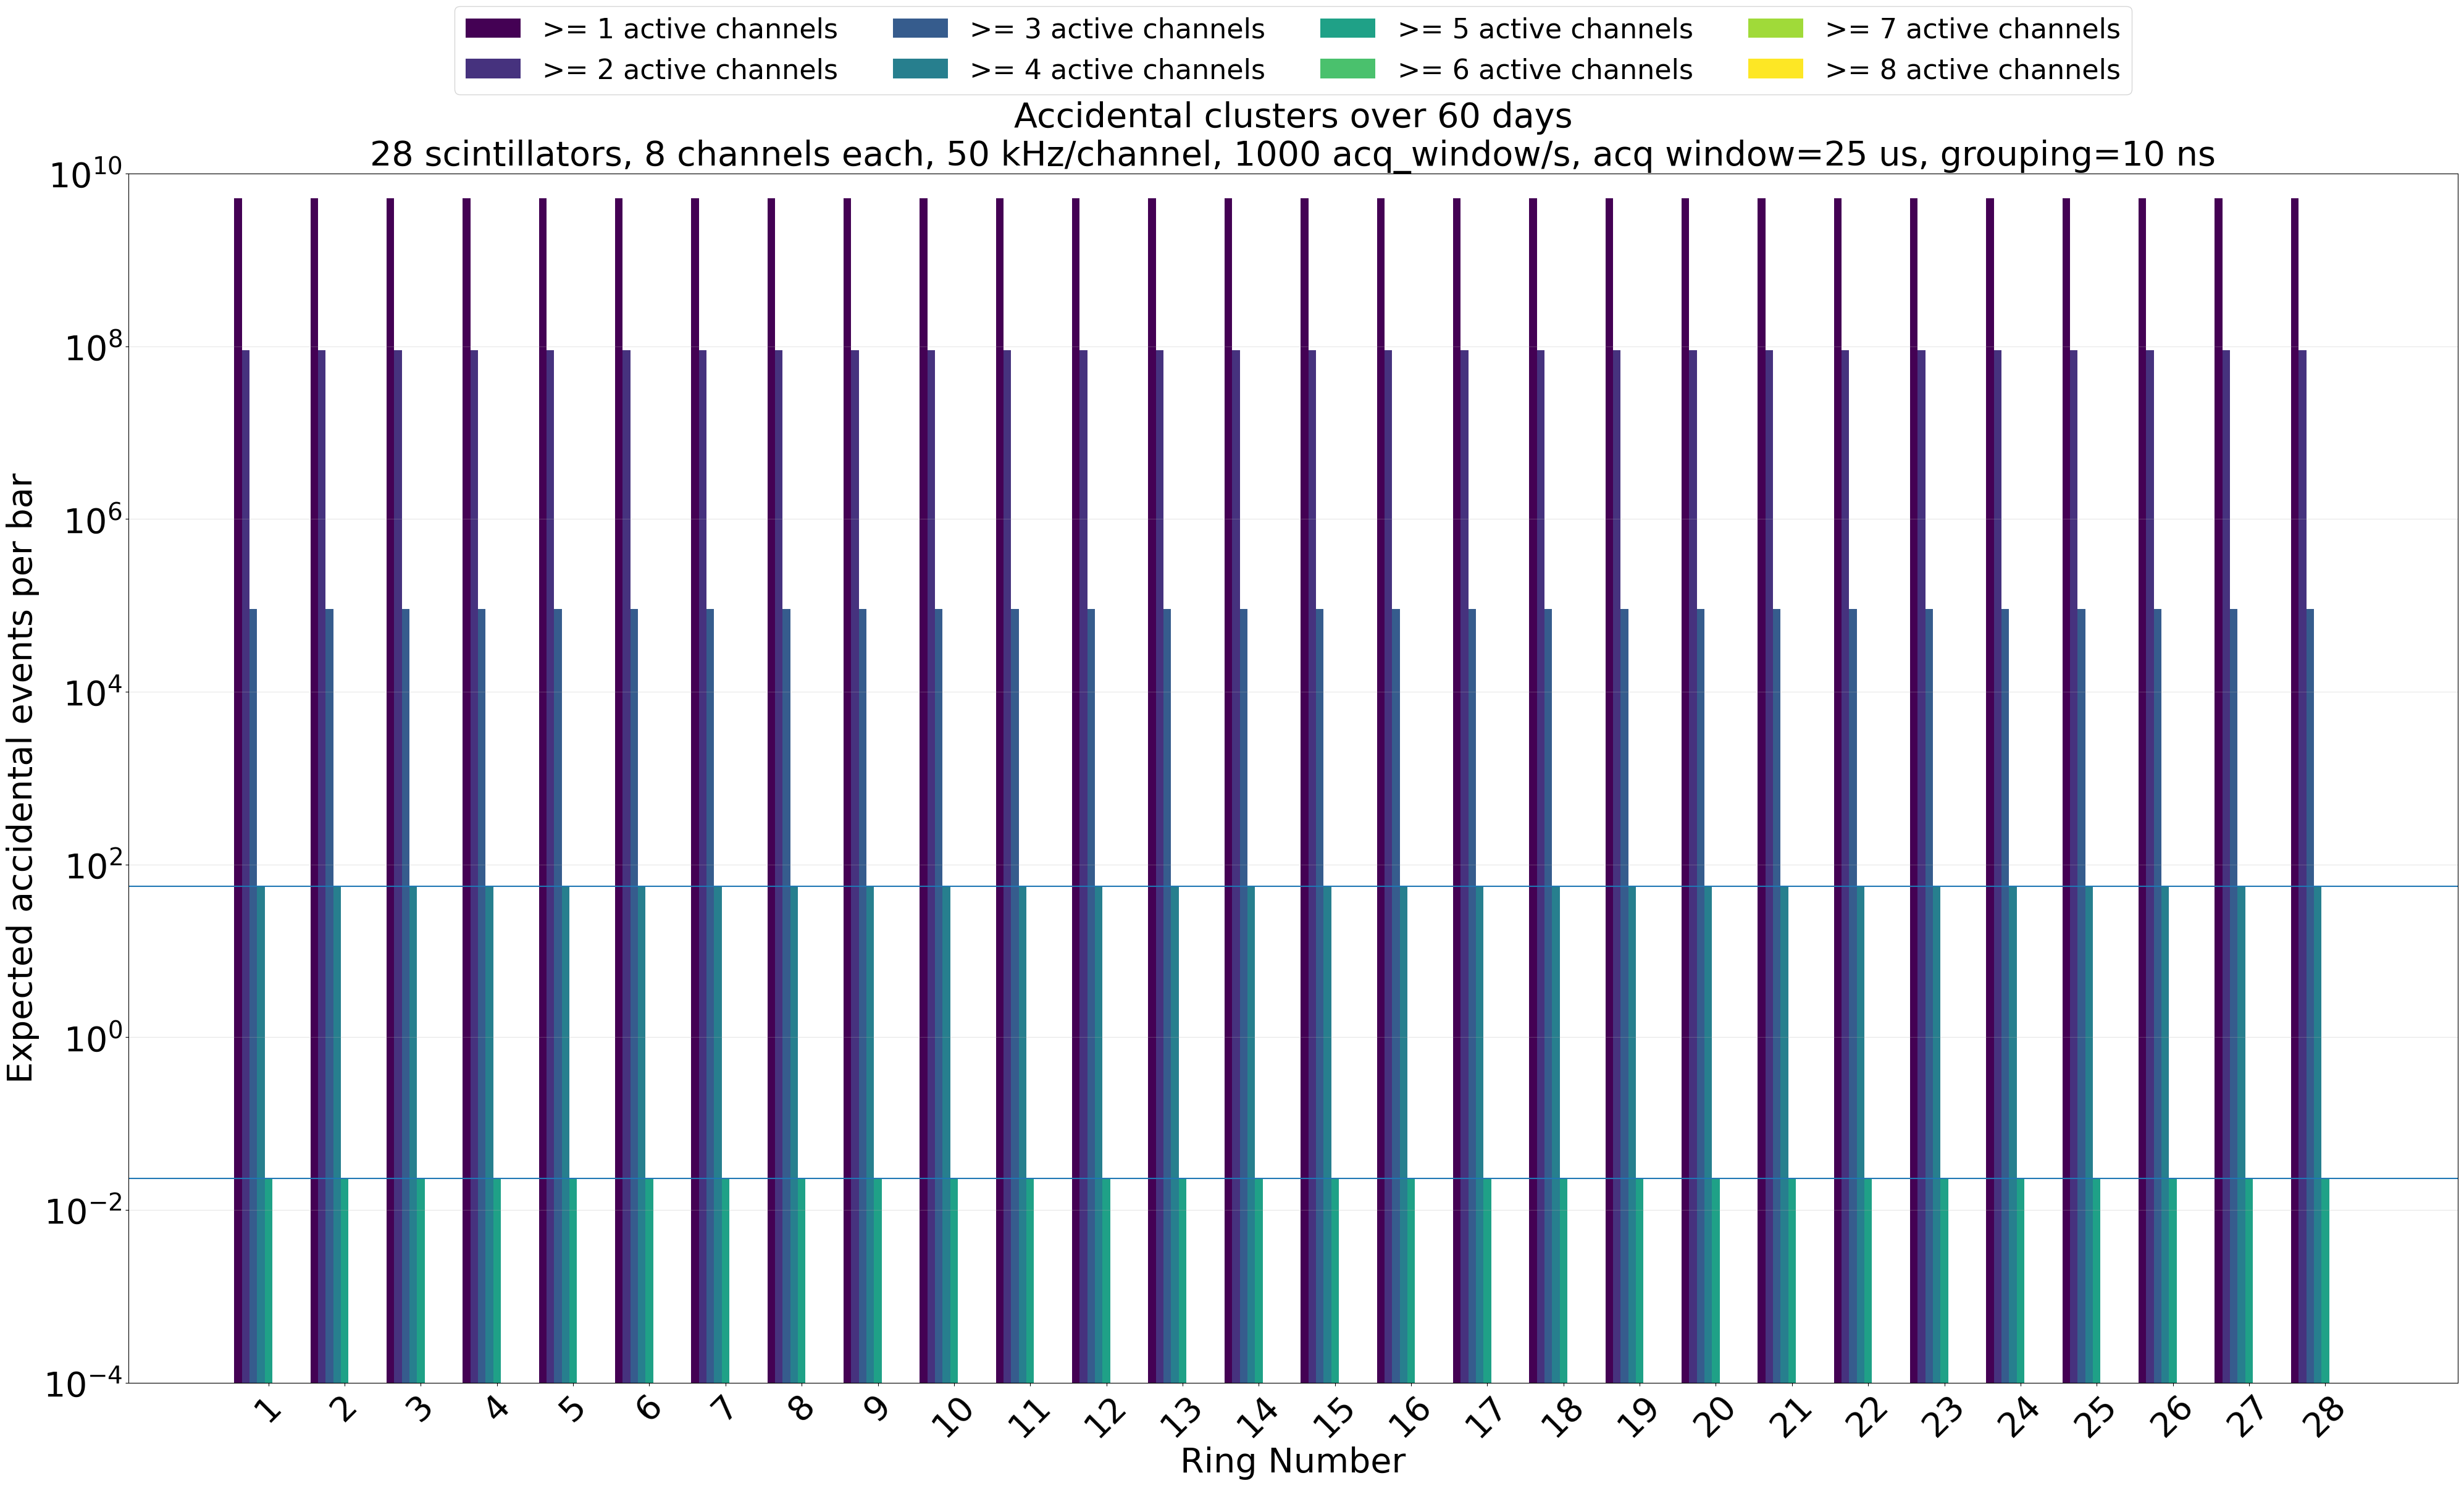

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

def expected_windowed_accidentals(
    n_scintillators=28,
    n_channels=8,
    rate_hz=50_000,
    grouping_window_s=10e-9,
    acquisition_window_s=25e-6,
    acquisition_windows_per_sec=1000,
    run_time_s=60*24*3600,
):
    """
    Expected accidental clusters per scintillator inside recorded acquisition windows.

    A cluster is defined as >=k active channels within grouping_window_s.
    But we only search inside acquisition_window_s windows,
    and only acquisition_windows_per_sec such windows are recorded.
    """

    p = 1 - np.exp(-rate_hz * grouping_window_s)

    thresholds = np.arange(1, n_channels + 1)

    expected_per_bar = np.zeros((n_scintillators, n_channels))
    rate_per_bar_hz = np.zeros(n_channels)
    prob_per_acq_window = np.zeros(n_channels)

    n_recorded_windows = acquisition_windows_per_sec * run_time_s

    # number of independent 10 ns grouping trials inside one 25 us window
    n_grouping_trials_per_acq = acquisition_window_s / grouping_window_s

    for i, k in enumerate(thresholds):

        # probability of >=k channels firing in one 10 ns grouping window
        prob_cluster_10ns = sum(
            comb(n_channels, j) * p**j * (1 - p)**(n_channels - j)
            for j in range(k, n_channels + 1)
        )

        # probability of at least one such cluster inside one 25 us acquisition window
        prob_cluster_acq = 1 - (1 - prob_cluster_10ns)**n_grouping_trials_per_acq

        # effective accidental rate per bar, considering only recorded windows
        effective_rate_hz = acquisition_windows_per_sec * prob_cluster_acq

        prob_per_acq_window[i] = prob_cluster_acq
        rate_per_bar_hz[i] = effective_rate_hz

        # expected counts per bar over full run
        expected_per_bar[:, i] = effective_rate_hz * run_time_s

    return thresholds, expected_per_bar, rate_per_bar_hz, prob_per_acq_window


# -------------------------------
# User inputs
# -------------------------------
n_scintillators = 28
n_channels = 8
rate_hz = 50_000

grouping_window_s = 10e-9      # 10 ns
acquisition_window_s = 25e-6   # 25 us
acquisition_windows_per_sec = 1000

run_time_s = 60 * 24 * 3600    # 2 months ~ 60 days

thresholds, expected, rate_per_bar_hz, prob_per_window = expected_windowed_accidentals(
    n_scintillators=n_scintillators,
    n_channels=n_channels,
    rate_hz=rate_hz,
    grouping_window_s=grouping_window_s,
    acquisition_window_s=acquisition_window_s,
    acquisition_windows_per_sec=acquisition_windows_per_sec,
    run_time_s=run_time_s,
)

# -------------------------------
# Print summary table
# -------------------------------
print("Accidental background per bar")
print("---------------------------------------------")
print("Requirement | P per 25us window | Rate/bar [Hz] | Events/bar in run")
print("---------------------------------------------")

for i, k in enumerate(thresholds):
    print(
        f">= {k:1d} channels | "
        f"{prob_per_window[i]:.3e} | "
        f"{rate_per_bar_hz[i]:.3e} | "
        f"{expected[0, i]:.3e}"
    )


# -------------------------------
# Plot grouped bar chart
# -------------------------------
rings = np.arange(1, n_scintillators + 1)

plt.figure(figsize=(40, 24))

bar_width = 0.1

colors = plt.cm.viridis(np.linspace(0, 1, 8))


for i, k in enumerate(thresholds):
    x = rings + (i - len(thresholds)/2) * bar_width
    plt.bar(
        x,
        expected[:, i],
        width=bar_width,color=colors[i],
        label=f">= {k} active channels"
    )



            
plt.xlabel("Ring Number",fontsize=40)
plt.ylabel("Expected accidental events per bar",fontsize=40)
plt.title(
    f"Accidental clusters over 60 days\n"
    f"{n_scintillators} scintillators, {n_channels} channels each, "
    f"{rate_hz/1000:.0f} kHz/channel, "
    f"{acquisition_windows_per_sec} acq_window/s, "
    f"acq window={acquisition_window_s*1e6:.0f} us, "
    f"grouping={grouping_window_s*1e9:.0f} ns"
,fontsize=40)

plt.yticks(fontsize=40)
plt.xticks(rings, rotation=45, fontsize=40)
plt.yscale("log")
plt.ylim([1e-4, 1e10])
plt.legend(
    fontsize=32,
    ncol=4,                 # 4 columns (2x4 structure)
    loc='upper center',     # Anchor location
    bbox_to_anchor=(0.5, 1.15), # Position above plot
    title_fontsize=23       # Slightly larger title
)
plt.axhline(y=56)

plt.axhline(y=0.023)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Accidental background per bar
---------------------------------------------
Requirement | P per 25us window | Rate/bar [Hz] | Events/bar in run
---------------------------------------------
>= 1 channels | 1.000e+00 | 1.000e+03 | 5.184e+09
>= 2 channels | 1.730e-02 | 1.730e+01 | 8.971e+07
>= 3 channels | 1.745e-05 | 1.745e-02 | 9.048e+04
>= 4 channels | 1.091e-08 | 1.091e-05 | 5.655e+01
>= 5 channels | 4.441e-12 | 4.441e-09 | 2.302e-02
>= 6 channels | 0.000e+00 | 0.000e+00 | 0.000e+00
>= 7 channels | 0.000e+00 | 0.000e+00 | 0.000e+00
>= 8 channels | 0.000e+00 | 0.000e+00 | 0.000e+00


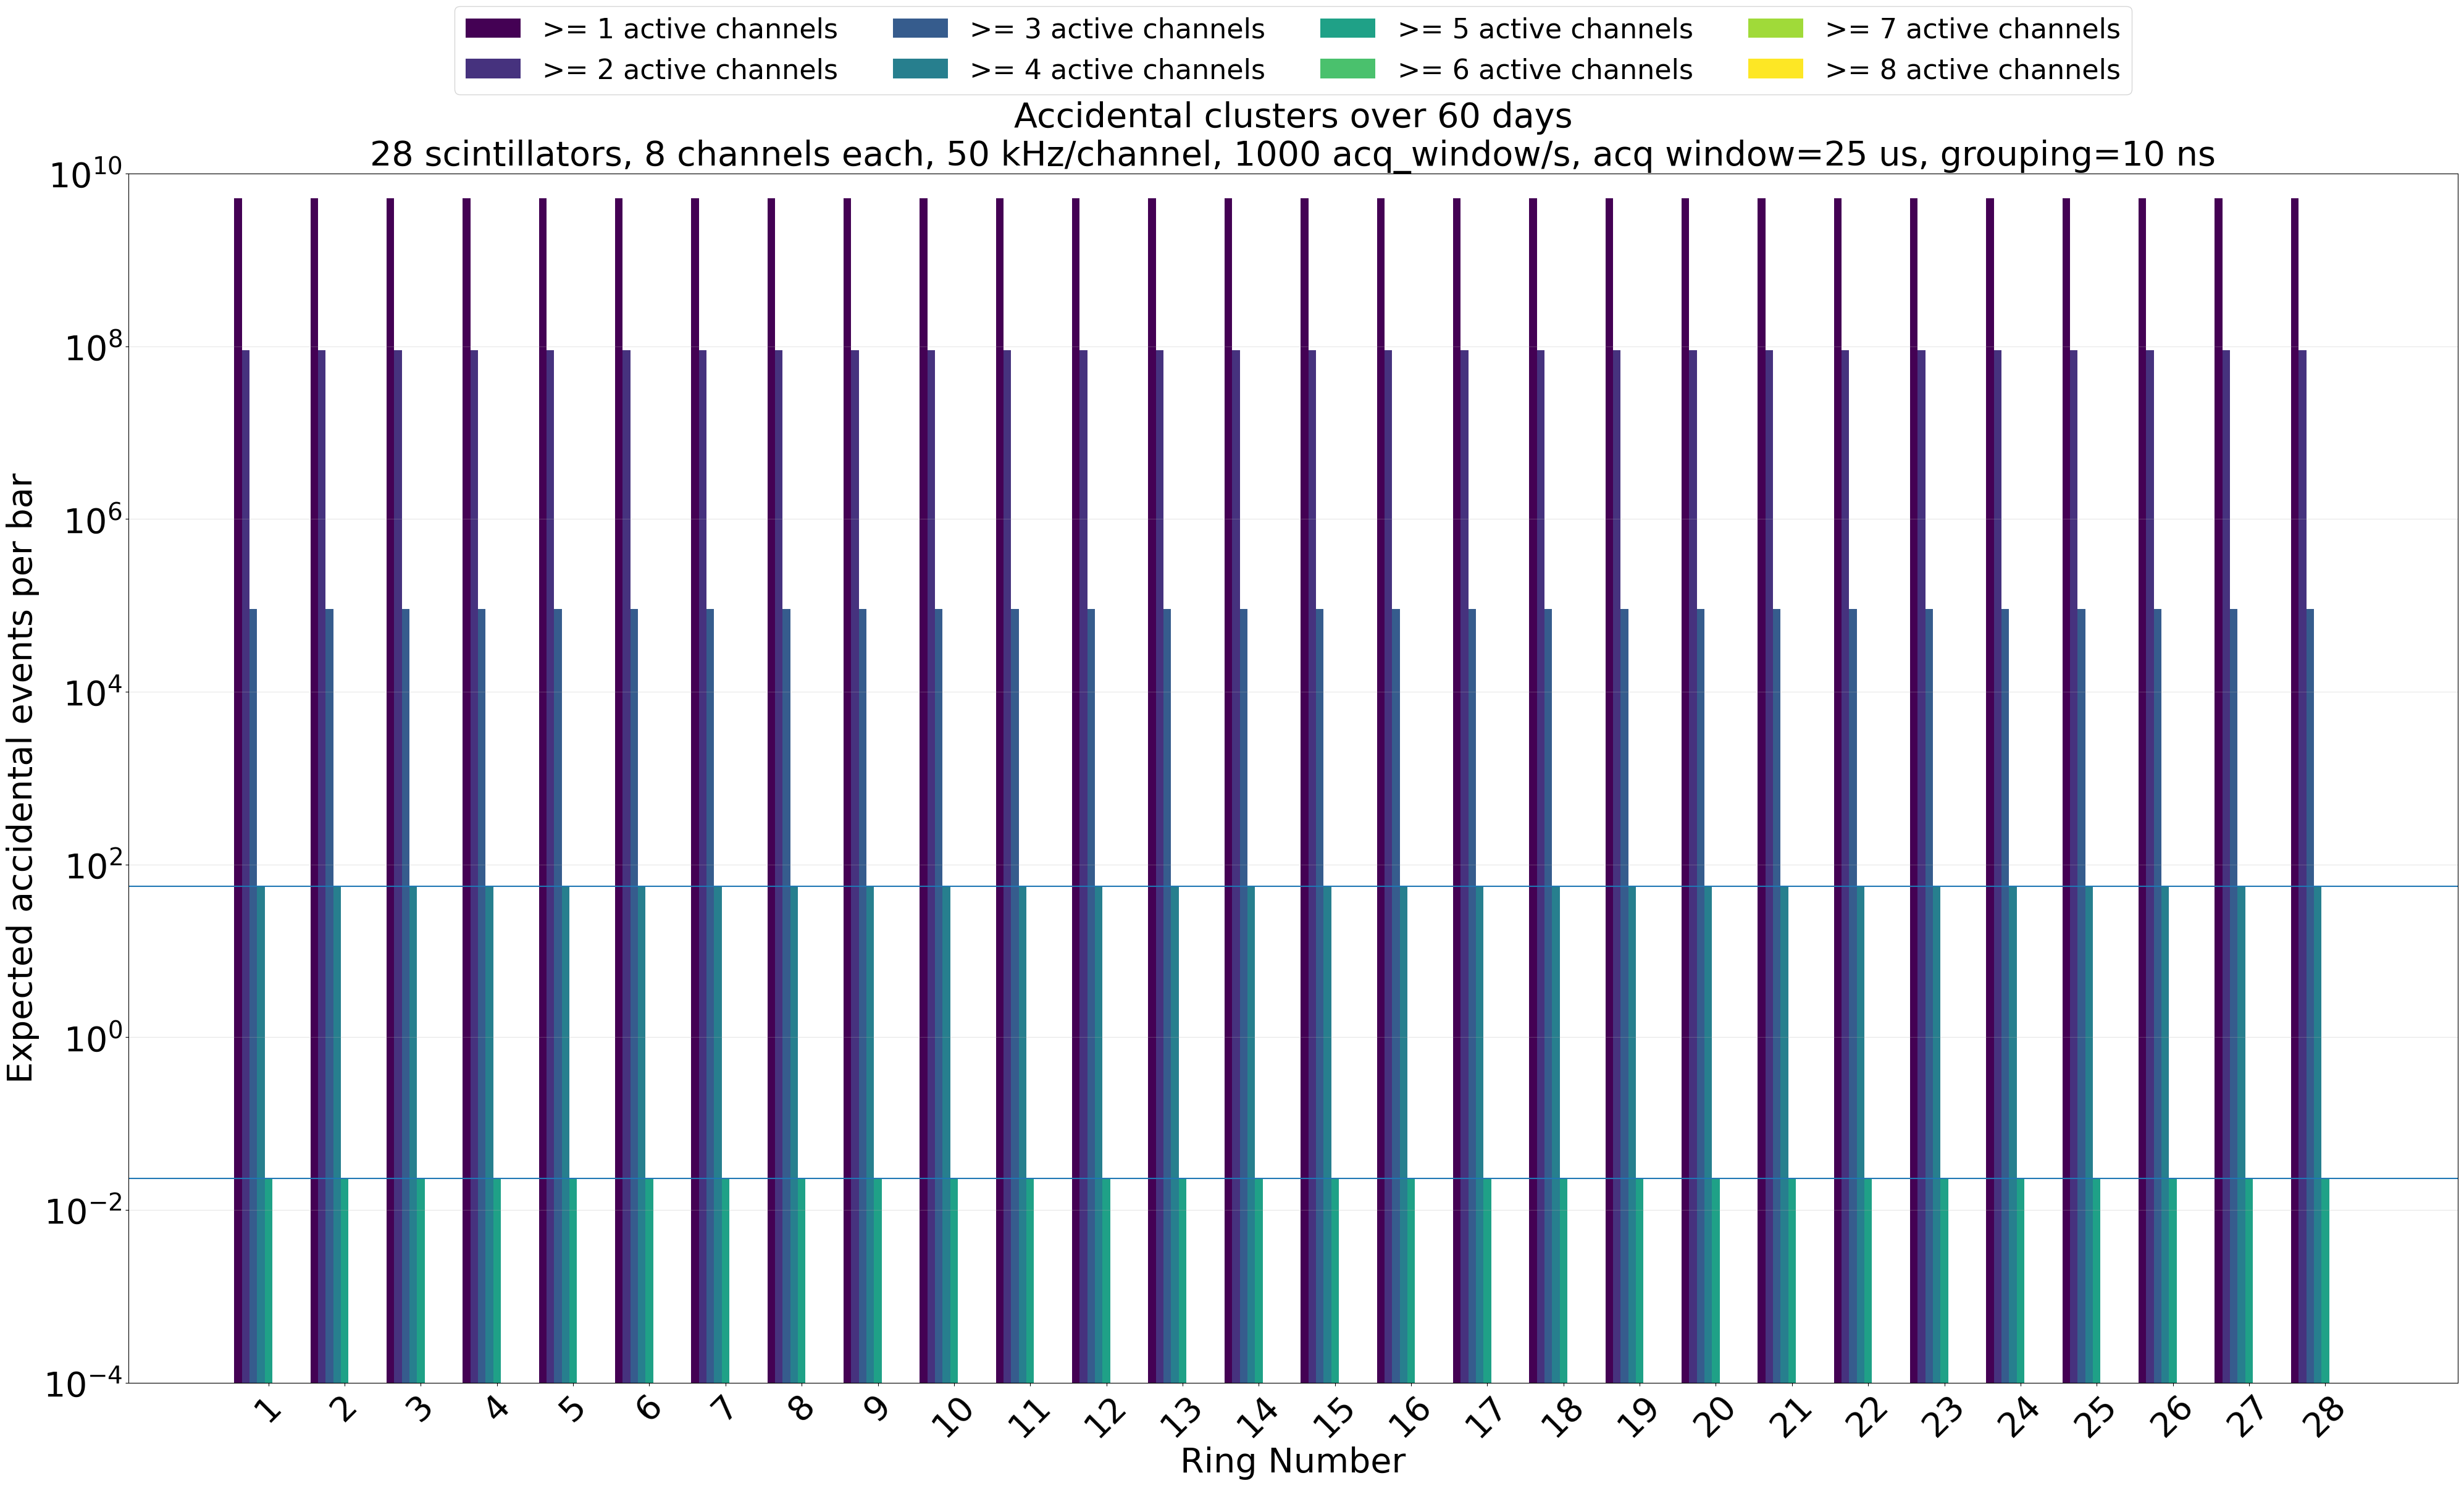

In [3]:

def expected_windowed_accidentals(
    n_scintillators=28,
    n_channels=8,
    rate_hz=50_000,
    grouping_window_s=10e-9,
    acquisition_window_s=25e-6,
    acquisition_windows_per_sec=1000,
    run_time_s=60*24*3600,
):
    """
    Expected accidental clusters per scintillator inside recorded acquisition windows.

    A cluster is defined as >=k active channels within grouping_window_s.
    But we only search inside acquisition_window_s windows,
    and only acquisition_windows_per_sec such windows are recorded.
    """

    p = 1 - np.exp(-rate_hz * grouping_window_s)

    thresholds = np.arange(1, n_channels + 1)

    expected_per_bar = np.zeros((n_scintillators, n_channels))
    rate_per_bar_hz = np.zeros(n_channels)
    prob_per_acq_window = np.zeros(n_channels)

    n_recorded_windows = acquisition_windows_per_sec * run_time_s

    # number of independent 10 ns grouping trials inside one 25 us window
    n_grouping_trials_per_acq = acquisition_window_s / grouping_window_s

    for i, k in enumerate(thresholds):

        # probability of >=k channels firing in one 10 ns grouping window
        prob_cluster_10ns = sum(
            comb(n_channels, j) * p**j * (1 - p)**(n_channels - j)
            for j in range(k, n_channels + 1)
        )

        # probability of at least one such cluster inside one 25 us acquisition window
        prob_cluster_acq = 1 - (1 - prob_cluster_10ns)**n_grouping_trials_per_acq

        # effective accidental rate per bar, considering only recorded windows
        effective_rate_hz = acquisition_windows_per_sec * prob_cluster_acq

        prob_per_acq_window[i] = prob_cluster_acq
        rate_per_bar_hz[i] = effective_rate_hz

        # expected counts per bar over full run
        expected_per_bar[:, i] = effective_rate_hz * run_time_s

    return thresholds, expected_per_bar, rate_per_bar_hz, prob_per_acq_window


# -------------------------------
# User inputs
# -------------------------------
n_scintillators = 28
n_channels = 8
rate_hz = 50_000

grouping_window_s = 10e-9      # 10 ns
acquisition_window_s = 25e-6   # 25 us
acquisition_windows_per_sec = 1000

run_time_s = 60 * 24 * 3600    # 2 months ~ 60 days

thresholds, expected, rate_per_bar_hz, prob_per_window = expected_windowed_accidentals(
    n_scintillators=n_scintillators,
    n_channels=n_channels,
    rate_hz=rate_hz,
    grouping_window_s=grouping_window_s,
    acquisition_window_s=acquisition_window_s,
    acquisition_windows_per_sec=acquisition_windows_per_sec,
    run_time_s=run_time_s,
)

# -------------------------------
# Print summary table
# -------------------------------
print("Accidental background per bar")
print("---------------------------------------------")
print("Requirement | P per 25us window | Rate/bar [Hz] | Events/bar in run")
print("---------------------------------------------")

for i, k in enumerate(thresholds):
    print(
        f">= {k:1d} channels | "
        f"{prob_per_window[i]:.3e} | "
        f"{rate_per_bar_hz[i]:.3e} | "
        f"{expected[0, i]:.3e}"
    )


# -------------------------------
# Plot grouped bar chart
# -------------------------------
rings = np.arange(1, n_scintillators + 1)

plt.figure(figsize=(40, 24))

bar_width = 0.1

colors = plt.cm.viridis(np.linspace(0, 1, 8))


for i, k in enumerate(thresholds):
    x = rings + (i - len(thresholds)/2) * bar_width
    plt.bar(
        x,
        expected[:, i],
        width=bar_width,color=colors[i],
        label=f">= {k} active channels"
    )



            
plt.xlabel("Ring Number",fontsize=40)
plt.ylabel("Expected accidental events per bar",fontsize=40)
plt.title(
    f"Accidental clusters over 60 days\n"
    f"{n_scintillators} scintillators, {n_channels} channels each, "
    f"{rate_hz/1000:.0f} kHz/channel, "
    f"{acquisition_windows_per_sec} acq_window/s, "
    f"acq window={acquisition_window_s*1e6:.0f} us, "
    f"grouping={grouping_window_s*1e9:.0f} ns"
,fontsize=40)

plt.yticks(fontsize=40)
plt.xticks(rings, rotation=45, fontsize=40)
plt.yscale("log")
plt.ylim([1e-4, 1e10])
plt.legend(
    fontsize=32,
    ncol=4,                 # 4 columns (2x4 structure)
    loc='upper center',     # Anchor location
    bbox_to_anchor=(0.5, 1.15), # Position above plot
    title_fontsize=23       # Slightly larger title
)
plt.axhline(y=56)

plt.axhline(y=0.023)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()




In [7]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
import matplotlib.colors as colors

def expected_acc_per_bar(
    n_channels=8,
    rate_hz=50_000,
    slow_rate_hz=5,
    grouping_window_s=10e-9,
    acquisition_window_s=25e-6,
    run_time_s=60*24*3600,
    k_required=4,
):
    # probability one channel fires in 10 ns
    p = 1 - np.exp(-rate_hz * grouping_window_s)

    # probability >= k channels fire in one 10 ns grouping window
    prob_cluster_10ns = sum(
        comb(n_channels, j) * p**j * (1 - p)**(n_channels - j)
        for j in range(k_required, n_channels + 1)
    )

    # number of 10 ns trials inside one 25 us event window
    n_trials = acquisition_window_s / grouping_window_s

    # probability at least one accidental cluster in one 25 us window
    prob_cluster_acq = 1 - (1 - prob_cluster_10ns)**n_trials

    # only slow-detector-hit windows matter
    acc_rate_per_bar_hz = slow_rate_hz * prob_cluster_acq

    # total expected accidentals per bar
    expected_per_bar = acc_rate_per_bar_hz * run_time_s

    return expected_per_bar




/tmp/ipykernel_470704/165615954.py:37: UserWarning: Log scale: values of z <= 0 have been masked
  cf = plt.contourf(


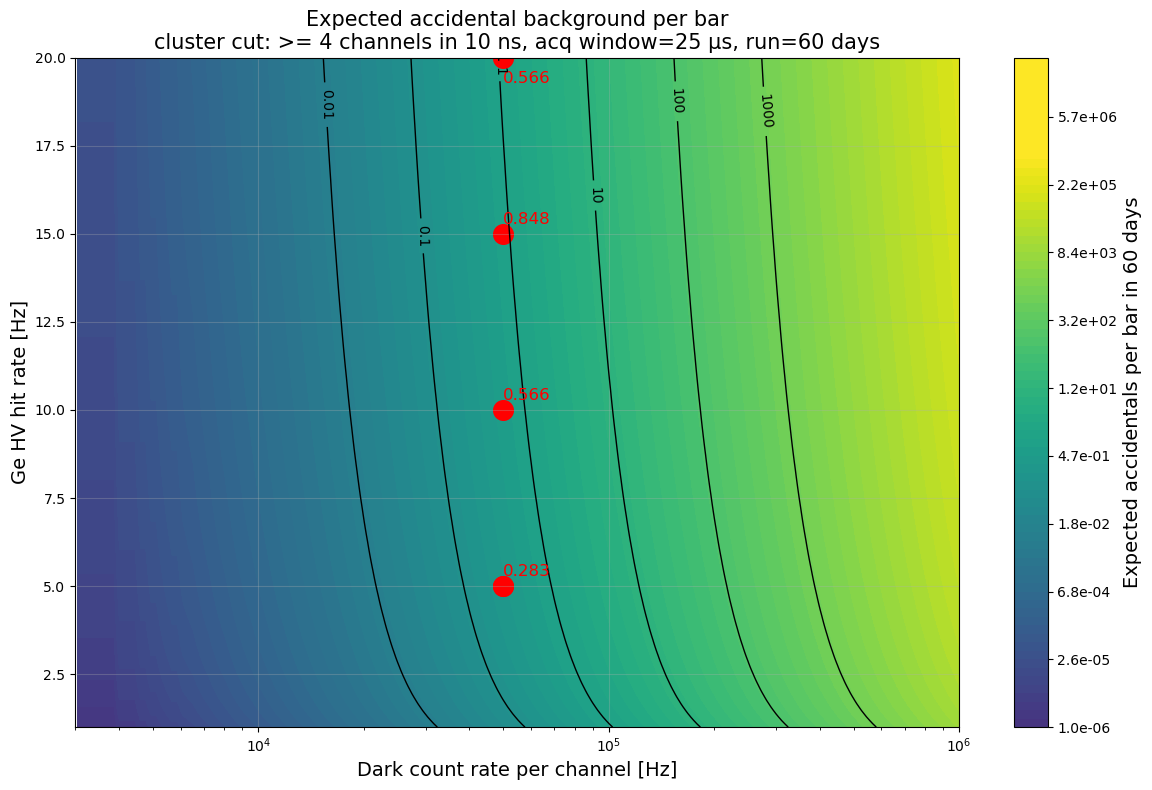

In [32]:
# -------------------------------
# User inputs
# -------------------------------
n_channels = 8
k_required = 4              # n >= 4 active channels
grouping_window_s = 10e-9   # 10 ns
acquisition_window_s = 25e-6
run_time_s = 60 * 24 * 3600 # 60 days

# scan ranges
rate_values = np.logspace(3, 6, 200)   # 1 kHz to 1 MHz
slow_values = np.linspace(1, 20, 200)  # 1 Hz to 20 Hz

R, S = np.meshgrid(rate_values, slow_values)

Z = np.zeros_like(R)

for i in range(S.shape[0]):
    for j in range(R.shape[1]):
        Z[i, j] = expected_acc_per_bar(
            n_channels=n_channels,
            rate_hz=R[i, j],
            slow_rate_hz=S[i, j],
            grouping_window_s=grouping_window_s,
            acquisition_window_s=acquisition_window_s,
            run_time_s=run_time_s,
            k_required=k_required,
        )

# -------------------------------
# 2D plot
# -------------------------------
plt.figure(figsize=(12, 8))

levels = np.logspace(-6, 8, 80)

cf = plt.contourf(
    R,
    S,
    Z,
    levels=levels,
    norm=colors.LogNorm()
)



# 1. Set the data range (limits)
cf.set_clim(vmin=1e-8, vmax=1e6) 

# 1. Create the colorbar
cbar = plt.colorbar(cf)
# 2. Set format to scientific notation (1e-05)
cbar.formatter = ticker.FormatStrFormatter('%.1e')
cbar.update_ticks()
# 3. Adjust font size
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Expected accidentals per bar in 60 days", fontsize=14)



# useful contour lines
contour_levels = [0.01, 0.1, 1, 10, 100, 1000]
cs = plt.contour(
    R,
    S,
    Z,
    levels=contour_levels,
    colors="black",
    linewidths=1
)
plt.clabel(cs, inline=True, fontsize=10, fmt="%g")

plt.xscale("log")
plt.xlabel("Dark count rate per channel [Hz]", fontsize=14)
plt.ylabel("Ge HV hit rate [Hz]", fontsize=14)
plt.xlim(3e3,1e6)
plt.scatter(5e4,5, color='r', s=200)


plt.title(
    f"Expected accidental background per bar\n"
    f"cluster cut: >= {k_required} channels in {grouping_window_s*1e9:.0f} ns, "
    f"acq window={acquisition_window_s*1e6:.0f} µs, run=60 days",
    fontsize=15
)


#### text 

plt.scatter(5e4, 5, color='r', s=200)

nominal = expected_acc_per_bar(
    rate_hz=50_000,
    slow_rate_hz=5,
    k_required=4
)

# label the point
plt.text(
    5e4, 5.2,
    f"{nominal:.3g}",
    color='red',
    fontsize=12,
    ha='left',
    va='bottom'
)


plt.scatter(5e4, 10, color='r', s=200)

nominal = expected_acc_per_bar(
    rate_hz=50_000,
    slow_rate_hz=10,
    k_required=4
)

# label the point
plt.text(
    5e4, 10.2,
    f"{nominal:.3g}",
    color='red',
    fontsize=12,
    ha='left',
    va='bottom'
)

plt.scatter(5e4, 15, color='r', s=200)

nominal = expected_acc_per_bar(
    rate_hz=50_000,
    slow_rate_hz=15,
    k_required=4
)

# label the point
plt.text(
    5e4, 15.2,
    f"{nominal:.3g}",
    color='red',
    fontsize=12,
    ha='left',
    va='bottom'
)

plt.scatter(5e4, 20, color='r', s=200)

nominal = expected_acc_per_bar(
    rate_hz=50_000,
    slow_rate_hz=10,
    k_required=4
)

# label the point
plt.text(
    5e4, 19.2,
    f"{nominal:.3g}",
    color='red',
    fontsize=12,
    ha='left',
    va='bottom'
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

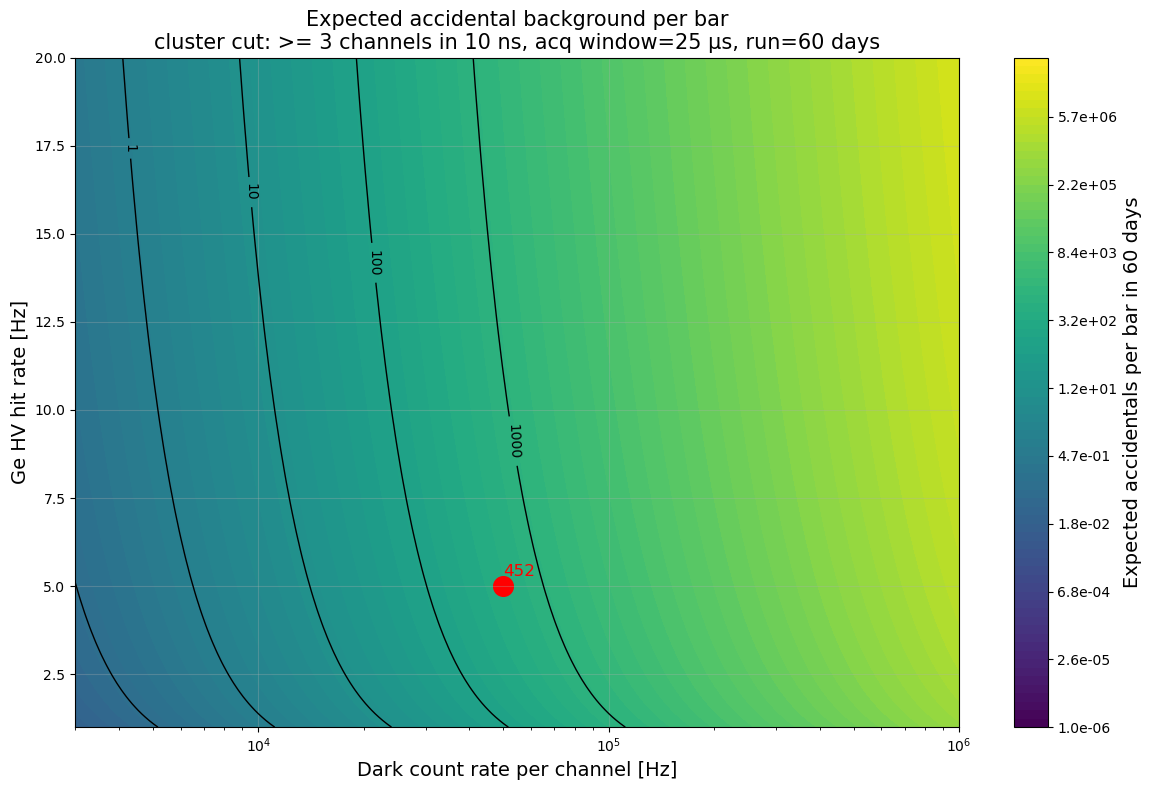

In [30]:
# -------------------------------
# User inputs
# -------------------------------
n_channels = 8
k_required = 3              # n >= 4 active channels
grouping_window_s = 10e-9   # 10 ns
acquisition_window_s = 25e-6
run_time_s = 60 * 24 * 3600 # 60 days

# scan ranges
rate_values = np.logspace(3, 6, 200)   # 1 kHz to 1 MHz
slow_values = np.linspace(1, 20, 200)  # 1 Hz to 20 Hz

R, S = np.meshgrid(rate_values, slow_values)

Z = np.zeros_like(R)

for i in range(S.shape[0]):
    for j in range(R.shape[1]):
        Z[i, j] = expected_acc_per_bar(
            n_channels=n_channels,
            rate_hz=R[i, j],
            slow_rate_hz=S[i, j],
            grouping_window_s=grouping_window_s,
            acquisition_window_s=acquisition_window_s,
            run_time_s=run_time_s,
            k_required=k_required,
        )

# -------------------------------
# 2D plot
# -------------------------------
plt.figure(figsize=(12, 8))

levels = np.logspace(-6, 8, 80)

cf = plt.contourf(
    R,
    S,
    Z,
    levels=levels,
    norm=colors.LogNorm()
)





# 1. Create the colorbar
cbar = plt.colorbar(cf)
# 2. Set format to scientific notation (1e-05)
cbar.formatter = ticker.FormatStrFormatter('%.1e')
cbar.update_ticks()
# 3. Adjust font size
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Expected accidentals per bar in 60 days", fontsize=14)



# useful contour lines
contour_levels = [0.01, 0.1, 1, 10, 100, 1000]
cs = plt.contour(
    R,
    S,
    Z,
    levels=contour_levels,
    colors="black",
    linewidths=1
)
plt.clabel(cs, inline=True, fontsize=10, fmt="%g")

plt.xscale("log")
plt.xlabel("Dark count rate per channel [Hz]", fontsize=14)
plt.ylabel("Ge HV hit rate [Hz]", fontsize=14)
plt.xlim(3e3,1e6)
plt.title(
    f"Expected accidental background per bar\n"
    f"cluster cut: >= {k_required} channels in {grouping_window_s*1e9:.0f} ns, "
    f"acq window={acquisition_window_s*1e6:.0f} µs, run=60 days",
    fontsize=15
)
plt.scatter(5e4, 5, color='r', s=200)

nominal = expected_acc_per_bar(
    rate_hz=50_000,
    slow_rate_hz=5,
    k_required=3
)

# label the point
plt.text(
    5e4, 5.2,
    f"{nominal:.3g}",
    color='red',
    fontsize=12,
    ha='left',
    va='bottom'
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()